In [11]:
# ADDITIONAL EXERCISE 1

from collections import defaultdict, Counter

# Required Inputs
SEED_NUM = 6
STUDENT_MAJOR = "BSME"
FAVORITE_ARTIST = "BTS"
LOCAL_HAZARD = "TYPHOON"
CONTROL_NUM = max(3, SEED_NUM)  # = 6

# Base stream
stream = [
    ("TUP Manila", "BSECE"),
    ("TUP Taguig", f"BSME_v{CONTROL_NUM}"),
    ("TUP Manila", f"BSME_v{CONTROL_NUM}"),
    ("TUP Manila", "BSECE"),
    ("TUP Visayas", STUDENT_MAJOR),
    ("TUP Taguig", "BSECE"),
    ("TUP Manila", "BSECE")
]

# Data Expansion: add exactly (CONTROL_NUM + 3) = 9 custom tuples
custom_apps = [
    ("TUP Manila", "BSECE"),
    ("TUP Manila", "BSME"),
    ("TUP Manila", "BSECE"),
    ("TUP Taguig", "BSIE"),
    ("TUP Taguig", "BSME"),
    ("TUP Visayas", "BSECE"),
    ("TUP Manila", "BSECE"),
    ("TUP Cavite", "BSME"),
    ("TUP Cavite", "BSECE"),
]
stream.extend(custom_apps)

print(f"Expanded Stream Length: {len(stream)}")

# Algorithm Phase 1: Aggregation
campus_dict = defaultdict(list)
for campus, program in stream:
    campus_dict[campus].append(program)

# Algorithm Phase 2: Frequency Analysis
for campus, programs in campus_dict.items():
    counter = Counter(programs)
    print(f"\n{campus}: {dict(counter)}")

manila_counter = Counter(campus_dict["TUP Manila"])
top_program, top_freq = manila_counter.most_common(1)[0]

print(f"\nTotal Applications for TUP Manila: {len(campus_dict['TUP Manila'])}")
print(f"Top Requested Program at TUP Manila: {top_program}")
print(f"Exact Frequency of Top Program: {top_freq}")

Expanded Stream Length: 16

TUP Manila: {'BSECE': 6, 'BSME_v6': 1, 'BSME': 1}

TUP Taguig: {'BSME_v6': 1, 'BSECE': 1, 'BSIE': 1, 'BSME': 1}

TUP Visayas: {'BSME': 1, 'BSECE': 1}

TUP Cavite: {'BSME': 1, 'BSECE': 1}

Total Applications for TUP Manila: 8
Top Requested Program at TUP Manila: BSECE
Exact Frequency of Top Program: 6


In [12]:
# ADDITIONAL EXERCISE 2

# Required Inputs
CONTROL_NUM = 6
FAVORITE_ARTIST = "BTS"

# Festival lineup
festival = {"Ben&Ben", "SB19", "Bini", "Eraserheads", FAVORITE_ARTIST,
            "Zild", f"Indie Artist {CONTROL_NUM}"}

# User profiles
user_a = {"Ben&Ben", "Bini", "Maki", "Dionela", FAVORITE_ARTIST}
user_b = {"SB19", "Eraserheads", "Zild", f"Indie Artist {CONTROL_NUM}",
          "Parokya ni Edgar"}

# Data Expansion: add exactly CONTROL_NUM = 6 new artists to festival
festival.update({"December Avenue", "Moira Dela Torre", "IV of Spades",
                 "Cup of Joe", "Nobita", "Adie"})

print(f"Total Artists in Expanded Festival: {len(festival)}")

# Jaccard Similarity for User A
intersection_a = user_a & festival
union_a = user_a | festival
jaccard_a = (len(intersection_a) / len(union_a)) * 100

print(f"\nIntersection (User A & Festival): {intersection_a}")
print(f"Length of Intersection (User A): {len(intersection_a)}")
print(f"Length of Union (User A): {len(union_a)}")
print(f"User A Jaccard Similarity: {jaccard_a:.2f}%")

# Jaccard Similarity for User B
intersection_b = user_b & festival
union_b = user_b | festival
jaccard_b = (len(intersection_b) / len(union_b)) * 100

print(f"\nUser B Jaccard Similarity: {jaccard_b:.2f}%")

# Dealbreakers: artists User A listens to NOT in festival
dealbreakers_a = user_a - festival
print(f"\nUser A Dealbreaker Artists: {dealbreakers_a}")

Total Artists in Expanded Festival: 13

Intersection (User A & Festival): {'Ben&Ben', 'BTS', 'Bini'}
Length of Intersection (User A): 3
Length of Union (User A): 15
User A Jaccard Similarity: 20.00%

User B Jaccard Similarity: 28.57%

User A Dealbreaker Artists: {'Dionela', 'Maki'}


In [13]:
# ADDITIONAL EXERCISE 3

from collections import deque, Counter

# Required Inputs
CONTROL_NUM = 6
LOCAL_HAZARD = "TYPHOON"

# Deque with maxlen=5
alert_buffer = deque(maxlen=5)

# Base burst
burst = [
    (CONTROL_NUM,     "WEATHER"),
    (CONTROL_NUM + 1, "TRAFFIC"),
    (CONTROL_NUM + 2, "WEATHER"),
    (CONTROL_NUM + 3, "WEATHER"),   # <-- will this append?
    (CONTROL_NUM + 4, LOCAL_HAZARD),
    (CONTROL_NUM + 5, "WEATHER"),
    (CONTROL_NUM + 6, "TRAFFIC")
]

# Data Expansion: append exactly (CONTROL_NUM + 2) = 8 custom alerts
# Timestamps continue from CONTROL_NUM + 7 = 13
custom_alerts = [
    (CONTROL_NUM + 7,  "TRAFFIC"),
    (CONTROL_NUM + 8,  LOCAL_HAZARD),
    (CONTROL_NUM + 9,  "WEATHER"),
    (CONTROL_NUM + 10, "TRAFFIC"),
    (CONTROL_NUM + 11, LOCAL_HAZARD),
    (CONTROL_NUM + 12, "WEATHER"),
    (CONTROL_NUM + 13, "TRAFFIC"),
    (CONTROL_NUM + 14, "WEATHER"),
]
burst.extend(custom_alerts)

print(f"Total Burst Size: {len(burst)}")

# Sliding Window Filter
for timestamp, category in burst:
    current_categories = [alert[1] for alert in alert_buffer]
    cat_counter = Counter(current_categories)
    if cat_counter[category] >= 2:
        print(f"  REJECTED -> Timestamp {timestamp} | Category: {category}")
    else:
        alert_buffer.append((timestamp, category))
        print(f"  ACCEPTED -> Timestamp {timestamp} | Category: {category}")

print(f"\nFinal Deque Length: {len(alert_buffer)}")
timestamp_sum = sum(alert[0] for alert in alert_buffer)
print(f"Final Sum of Timestamps in Deque: {timestamp_sum}")
print(f"Exact Final Deque Output: {alert_buffer}")

Total Burst Size: 15
  ACCEPTED -> Timestamp 6 | Category: WEATHER
  ACCEPTED -> Timestamp 7 | Category: TRAFFIC
  ACCEPTED -> Timestamp 8 | Category: WEATHER
  REJECTED -> Timestamp 9 | Category: WEATHER
  ACCEPTED -> Timestamp 10 | Category: TYPHOON
  REJECTED -> Timestamp 11 | Category: WEATHER
  ACCEPTED -> Timestamp 12 | Category: TRAFFIC
  REJECTED -> Timestamp 13 | Category: TRAFFIC
  ACCEPTED -> Timestamp 14 | Category: TYPHOON
  ACCEPTED -> Timestamp 15 | Category: WEATHER
  ACCEPTED -> Timestamp 16 | Category: TRAFFIC
  REJECTED -> Timestamp 17 | Category: TYPHOON
  ACCEPTED -> Timestamp 18 | Category: WEATHER
  REJECTED -> Timestamp 19 | Category: TRAFFIC
  REJECTED -> Timestamp 20 | Category: WEATHER

Final Deque Length: 5
Final Sum of Timestamps in Deque: 75
Exact Final Deque Output: deque([(12, 'TRAFFIC'), (14, 'TYPHOON'), (15, 'WEATHER'), (16, 'TRAFFIC'), (18, 'WEATHER')], maxlen=5)


# EXECUTION LOG

## Exercise 1 - Unstructured Data Aggregator
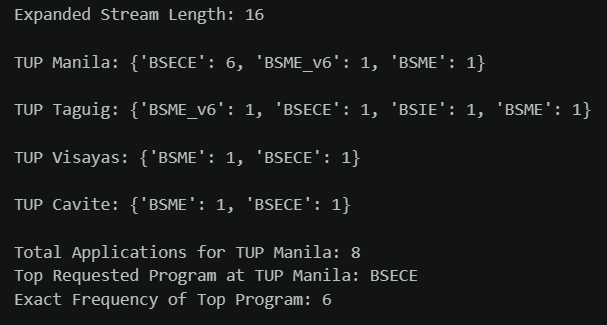

## Exercise 2 - Jaccard Similarity Engine
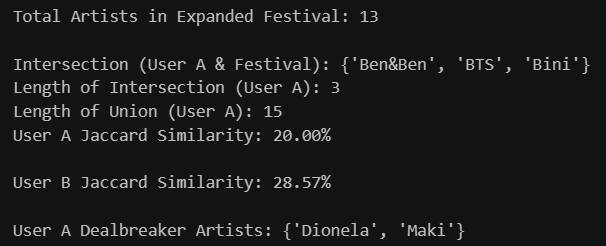

## Exercise 3 - Stateful Sliding Window Filter
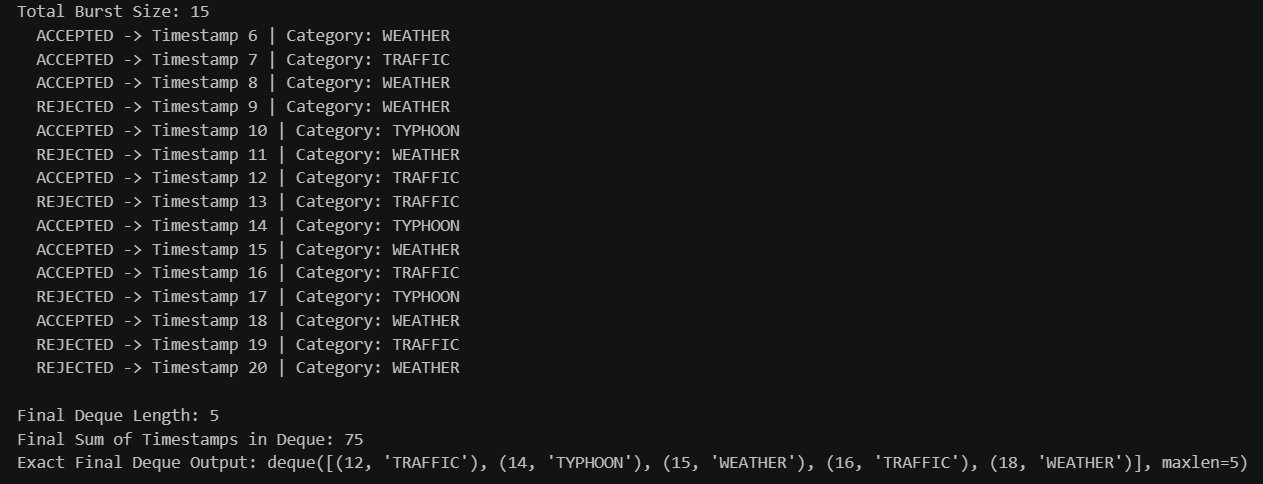